In [1]:
!pip install transformers
!pip install wordcloud


**Import the required libraries:**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')


In [3]:
from google.colab import files
uploaded = files.upload()


Saving Mental health.csv to Mental health (1).csv


**Read the CSV file**:

In [4]:
df = pd.read_csv('/content/Mental health.csv')  # Replace with your actual file name


**Inspect the dataset:**

In [5]:
df.head()


,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


**Step 4: Data Cleaning and Preparation**

In [7]:
# Step 4: Clean & Preprocess Data
df = df.dropna(subset=[
    '7. What social media platforms do you commonly use?',
    '18. How often do you feel depressed or down?'
] + df.columns[8:21].tolist())

# Binary Target: At risk (1) or not (0) based on depression score
y_raw = df['18. How often do you feel depressed or down?'].astype(int)
y = np.where(y_raw >= 4, 1, 0)

# Text data
text_data = df['7. What social media platforms do you commonly use?'].astype(str).tolist()

# Numeric survey responses
numeric_cols = df.columns[8:21].difference(['18. How often do you feel depressed or down?'])
numeric_data = df[numeric_cols]
X_num = numeric_data.apply(pd.to_numeric, errors='coerce').values

In [9]:
# Step 5: Generate BERT Embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings(texts):
    embeddings = []
    for text in texts:
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=50)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        cls_embed = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        embeddings.append(cls_embed)
    return np.array(embeddings)

X_bert = get_bert_embeddings(text_data)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [10]:
# Step 6: Combine BERT + Numeric Features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_combined = np.concatenate([X_bert, X_num_scaled], axis=1)

# Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


In [11]:
# Step 8: Build ANN Model
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

# Step 9: Train Model
history = model.fit(X_train, y_train, epochs=5, batch_size=16, validation_split=0.1, verbose=1)


Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5415 - loss: nan - val_accuracy: 0.5897 - val_loss: nan
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5271 - loss: nan - val_accuracy: 0.5897 - val_loss: nan
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5299 - loss: nan - val_accuracy: 0.5897 - val_loss: nan
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5264 - loss: nan - val_accuracy: 0.5897 - val_loss: nan
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5668 - loss: nan - val_accuracy: 0.5897 - val_loss: nan


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Classification Report:

              precision    recall  f1-score   support

 Not At Risk       0.54      1.00      0.70        52
     At Risk       0.00      0.00      0.00        45

    accuracy                           0.54        97
   macro avg       0.27      0.50      0.35        97
weighted avg       0.29      0.54      0.37        97



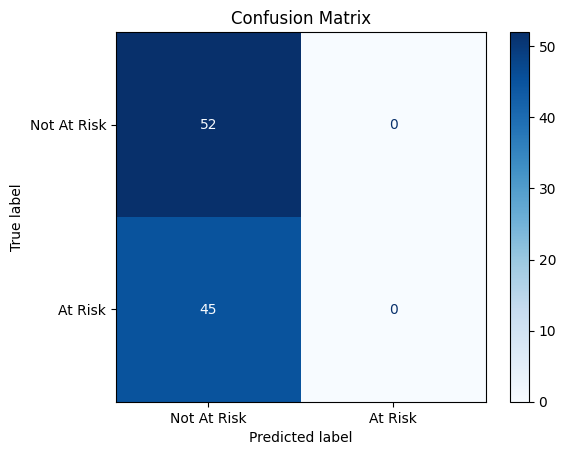

In [12]:
# Step 10: Evaluate Model
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Not At Risk", "At Risk"]))

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Not At Risk", "At Risk"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


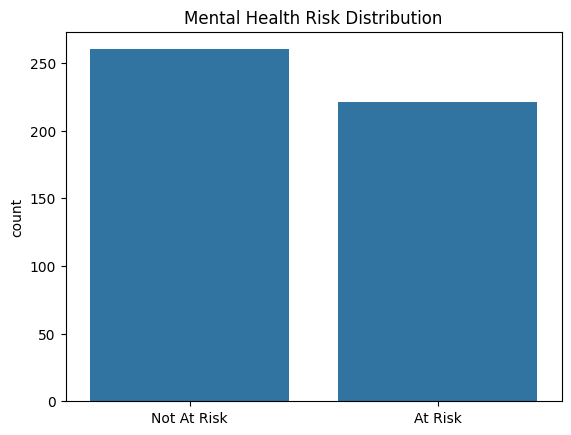

In [14]:
# Step 11: Visualizations

# 1. Class Distribution
sns.countplot(x=y)
plt.title("Mental Health Risk Distribution")
plt.xticks([0, 1], ["Not At Risk", "At Risk"])
plt.show()



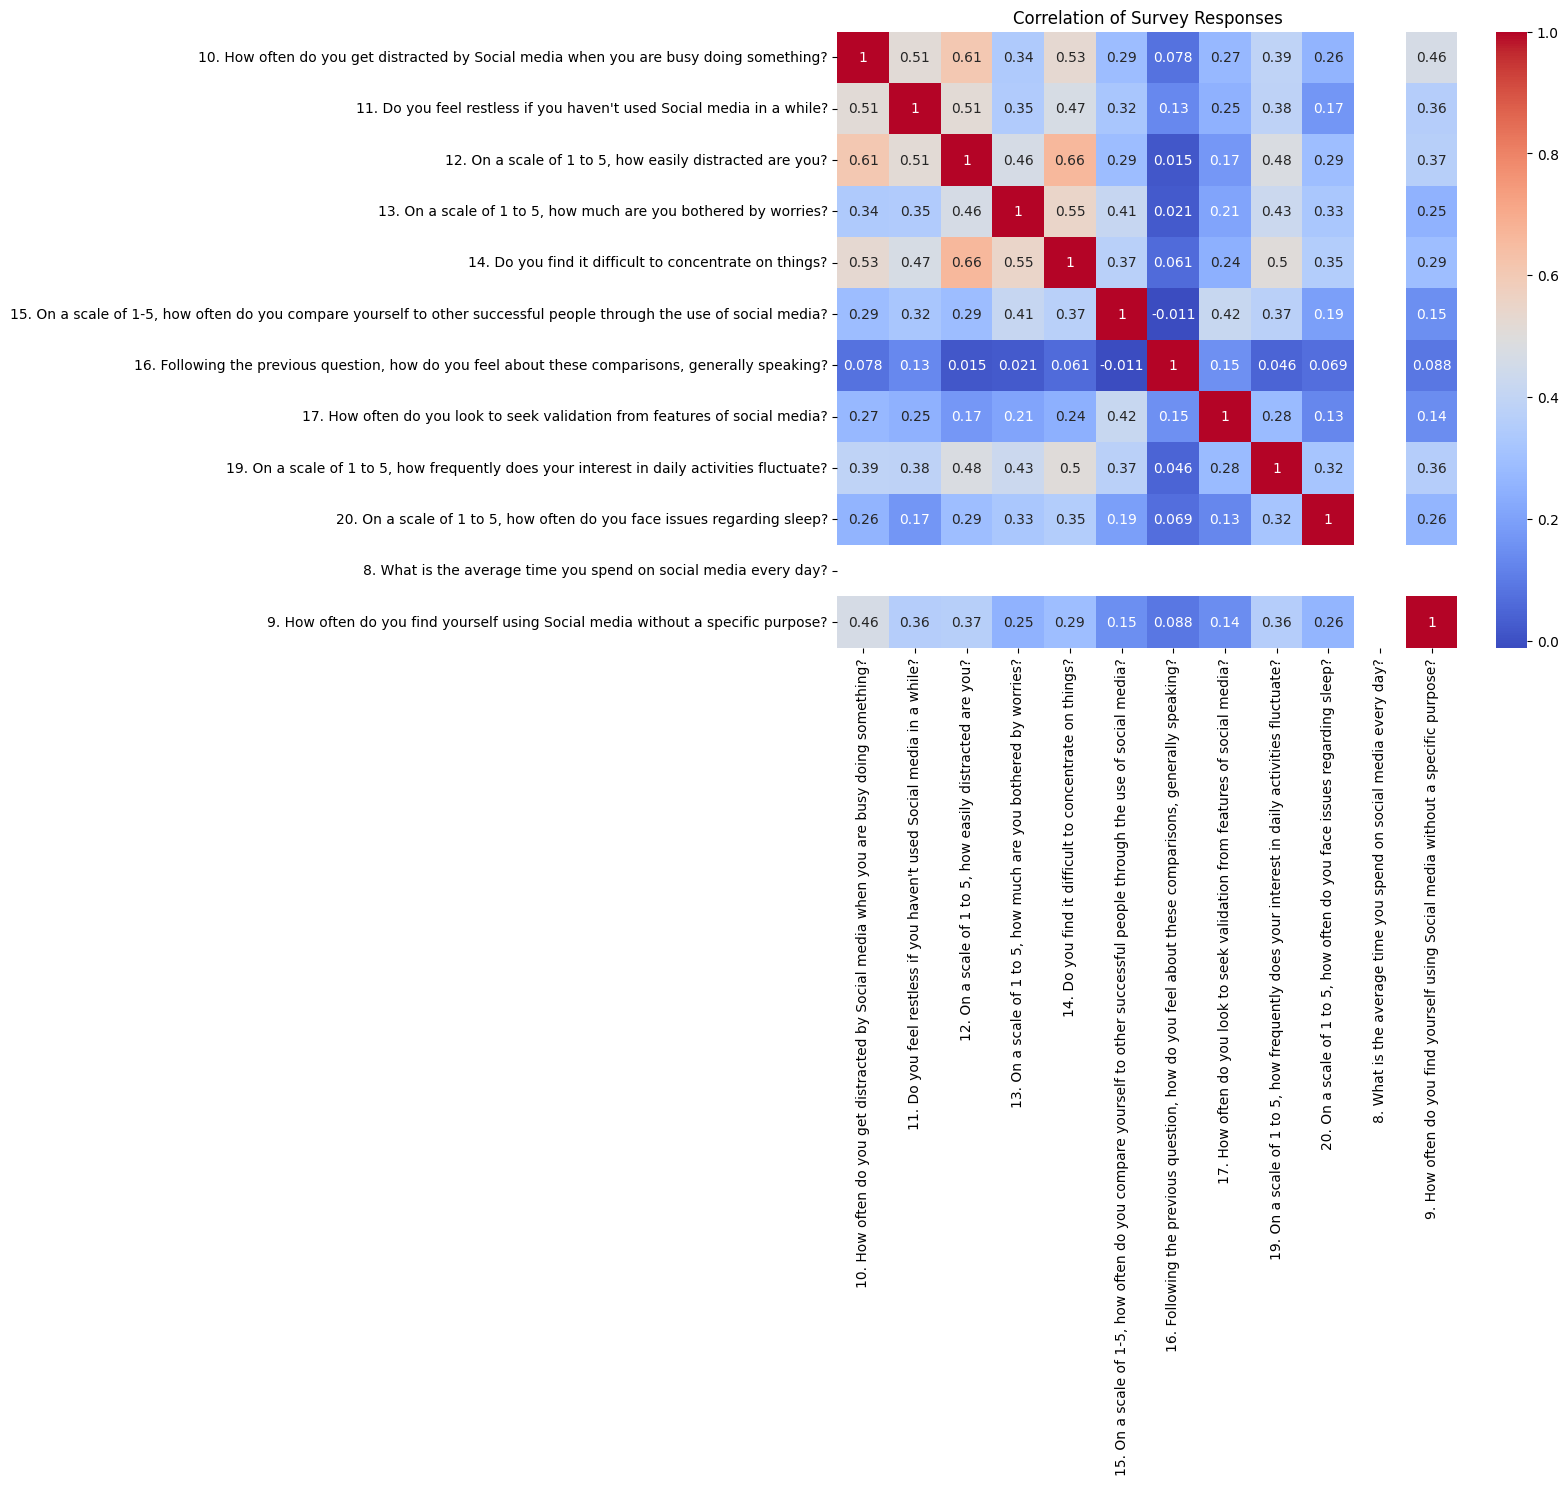

In [15]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = pd.DataFrame(X_num, columns=numeric_cols).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation of Survey Responses")
plt.show()




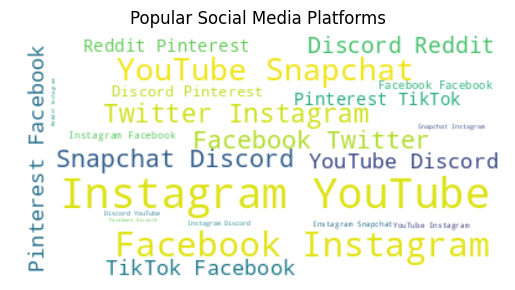

In [16]:
# 3. WordCloud of Platforms
text_all = " ".join(text_data)
wordcloud = WordCloud(background_color='white', max_words=100).generate(text_all)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Social Media Platforms")
plt.show()

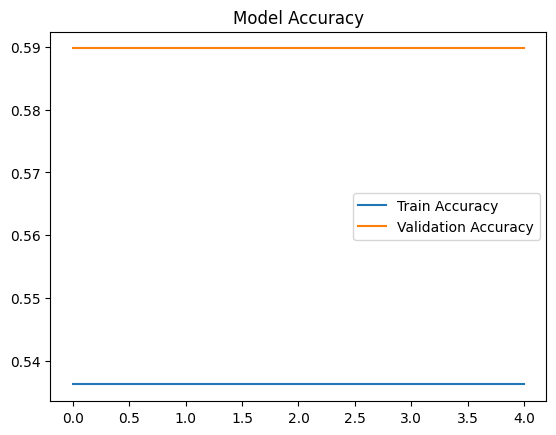

In [17]:
# 4. Accuracy & Loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()



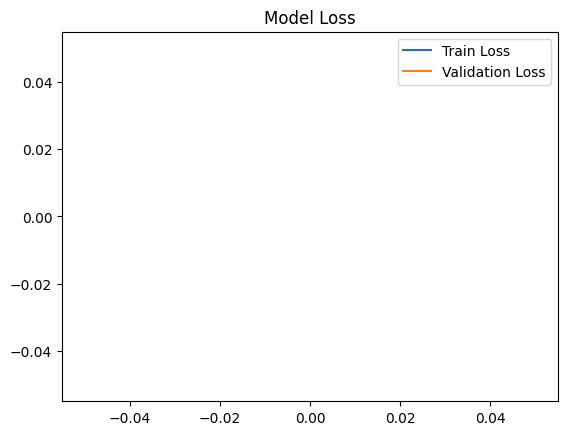

In [18]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()